## 04 — Regression Modeling

**Objective:** Predict `rating_title` (FotMob match rating) from 5-match rolling features.  
Train: 2021/22–2023/24 | Test: 2024/25  
Two feature sets: **baseline** (rolling stats only) and **enhanced** (+ context + strength features).  
Two model types: **Ridge** and **Random Forest**, both single and position-grouped.

**Stages:**
1. Setup & load data  
2. Baseline feature definition  
3. Mean predictor baselines  
4. Ridge — single, baseline features  
5. RF — single, baseline features  
6. Ridge — grouped, baseline features  
7. RF — grouped, baseline features  
8. Build enhanced features  
9. Ridge — single, enhanced features  
10. RF — single, enhanced features  
11. Ridge — grouped, enhanced features  
12. RF — grouped, enhanced features (final outfield model)  
13. GK models — baseline vs enhanced  
14. Full comparison table  
15. Visualisations  
16. Feature importance & Ridge coefficients  
17. Export models and predictions

### Cell 1 — Setup & load data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('data/processed/datasets')
MODELS_DIR    = Path('data/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

outfield_train = pd.read_parquet(PROCESSED_DIR / 'outfield_train_scaled.parquet')
outfield_test  = pd.read_parquet(PROCESSED_DIR / 'outfield_test_scaled.parquet')
gk_train       = pd.read_parquet(PROCESSED_DIR / 'gk_train_scaled.parquet')
gk_test        = pd.read_parquet(PROCESSED_DIR / 'gk_test_scaled.parquet')

# Columns never used as features
ID_COLS = [
    'match_id', 'round', 'match_date', 'home_team', 'away_team',
    'player_id', 'player_name', 'team_id', 'team_name', 'minutes_played',
    'shirt_number', 'position_id', 'is_goalkeeper', 'season',
    'opponent', 'team_goals_scored', 'opp_goals_scored', 'result',
    'position_group',
]
# Prediction cols from any previous run — must never be features
PRED_COLS = ['pred_rating_rf_base', 'pred_rating_rf_enh',
             'pred_rating_ridge_base', 'pred_rating_ridge_enh']

tscv   = TimeSeriesSplit(n_splits=5)
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 200.0, 500.0, 750.0,
          1000.0, 2000.0, 5000.0, 10000.0]
GROUPS       = ['defender', 'midfielder', 'winger', 'forward']
GROUP_COLORS = {'defender':'#2171b5','midfielder':'#238b45',
                'winger':'#d94801','forward':'#6a51a3'}

print(f'Outfield train : {outfield_train.shape[0]:,} x {outfield_train.shape[1]}')
print(f'Outfield test  : {outfield_test.shape[0]:,} x {outfield_test.shape[1]}')
print(f'GK train       : {gk_train.shape[0]:,} x {gk_train.shape[1]}')
print(f'GK test        : {gk_test.shape[0]:,} x {gk_test.shape[1]}')

Outfield train : 21,847 x 57
Outfield test  : 7,034 x 57
GK train       : 2,193 x 47
GK test        : 713 x 47


### Cell 2 — Helper functions

In [22]:
def evaluate(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'  {label:<48} RMSE:{rmse:.4f}  R²:{r2:.4f}')
    return {'label': label, 'mse': mse, 'rmse': rmse, 'r2': r2}

def print_table(results, title=''):
    if title:
        print(f'\n{"="*72}\n  {title}\n{"="*72}')
    print(f'  {"Model":<48} {"RMSE":>8} {"R²":>8}')
    print(f'  {"-"*66}')
    for r in results:
        print(f'  {r["label"]:<48} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}')

def avg_r2(results):   return np.mean([r['r2']   for r in results])
def avg_rmse(results): return np.mean([r['rmse'] for r in results])

def exhaustive_rf_search(X_tr, y_tr, label, param_grid):
    best_params, best_rmse, all_res = None, np.inf, []
    print(f'\n  {label} — {len(param_grid)} combos')
    for p in param_grid:
        rf  = RandomForestRegressor(**p, random_state=42, n_jobs=-1)
        s   = cross_val_score(rf, X_tr, y_tr, cv=tscv,
                              scoring='neg_root_mean_squared_error')
        mu  = -s.mean()
        all_res.append({**p, 'cv_rmse': mu, 'cv_std': s.std()})
        if mu < best_rmse:
            best_rmse, best_params = mu, p
    print(f'  Best: {best_params}  CV RMSE: {best_rmse:.4f}')
    return best_params, pd.DataFrame(all_res)

print('Helpers defined.')

Helpers defined.


### Cell 3 — Baseline feature columns (rolling stats only)

In [3]:
NON_FEAT_BASE = ID_COLS + PRED_COLS + ['rating_title',
                'home_away', 'self_strength', 'opp_strength',
                'opp_attack_strength', 'opp_rolling_xg',
                'opp_rolling_shots_ot', 'rolling_clean_sheet_rate']

FEATURE_COLS_OUT = [c for c in outfield_train.columns if c not in NON_FEAT_BASE]
FEATURE_COLS_GK  = [c for c in gk_train.columns       if c not in NON_FEAT_BASE]

X_train_out = outfield_train[FEATURE_COLS_OUT].values
X_test_out  = outfield_test[FEATURE_COLS_OUT].values
y_train_out = outfield_train['rating_title'].values
y_test_out  = outfield_test['rating_title'].values

X_train_gk  = gk_train[FEATURE_COLS_GK].values
X_test_gk   = gk_test[FEATURE_COLS_GK].values
y_train_gk  = gk_train['rating_title'].values
y_test_gk   = gk_test['rating_title'].values

print(f'Outfield baseline features : {len(FEATURE_COLS_OUT)}')
print(f'GK baseline features       : {len(FEATURE_COLS_GK)}')
print(f'X_train_out : {X_train_out.shape} | X_train_gk : {X_train_gk.shape}')

Outfield baseline features : 36
GK baseline features       : 26
X_train_out : (21847, 36) | X_train_gk : (2193, 26)


### Cell 4 — Mean predictor baselines

In [4]:
results_baseline = []
results_baseline.append(evaluate(
    y_test_out, np.full_like(y_test_out, y_train_out.mean()), 'Baseline mean — Outfield'))
results_baseline.append(evaluate(
    y_test_gk,  np.full_like(y_test_gk,  y_train_gk.mean()),  'Baseline mean — GK'))
print(f'\n  Outfield train mean : {y_train_out.mean():.4f}')
print(f'  GK train mean       : {y_train_gk.mean():.4f}')

  Baseline mean — Outfield                         RMSE:0.7944  R²:-0.0011
  Baseline mean — GK                               RMSE:1.1533  R²:-0.0031

  Outfield train mean : 7.0281
  GK train mean       : 6.8017


### Cell 5 — Ridge regression, single model (baseline features)

In [5]:
results_ridge_single = []

# Outfield
ridge_single_out = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_single_out.fit(X_train_out, y_train_out)
results_ridge_single.append(evaluate(
    y_test_out, ridge_single_out.predict(X_test_out), 'Ridge single — Outfield'))
print(f'  alpha={ridge_single_out.alpha_}')

# GK
ridge_single_gk = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_single_gk.fit(X_train_gk, y_train_gk)
results_ridge_single.append(evaluate(
    y_test_gk, ridge_single_gk.predict(X_test_gk), 'Ridge single — GK'))
print(f'  alpha={ridge_single_gk.alpha_}')

  Ridge single — Outfield                          RMSE:0.7764  R²:0.0440
  alpha=2000.0
  Ridge single — GK                                RMSE:1.1466  R²:0.0085
  alpha=200.0


### Cell 6 — RF single model, exhaustive grid (baseline features)

In [6]:
RF_GRID_BASE = [
    {'n_estimators': n, 'max_depth': d}
    for n in [200, 300, 500]
    for d in [5, 6, 7, 8, 9]
]
results_rf_single = []

best_out_base, _ = exhaustive_rf_search(X_train_out, y_train_out, 'Outfield', RF_GRID_BASE)
rf_single_out = RandomForestRegressor(**best_out_base, random_state=42, n_jobs=-1)
rf_single_out.fit(X_train_out, y_train_out)
results_rf_single.append(evaluate(
    y_test_out, rf_single_out.predict(X_test_out), 'RF single — Outfield'))

best_gk_base, _ = exhaustive_rf_search(X_train_gk, y_train_gk, 'GK', RF_GRID_BASE)
rf_single_gk = RandomForestRegressor(**best_gk_base, random_state=42, n_jobs=-1)
rf_single_gk.fit(X_train_gk, y_train_gk)
results_rf_single.append(evaluate(
    y_test_gk, rf_single_gk.predict(X_test_gk), 'RF single — GK'))


  Outfield — 15 combos
  Best: {'n_estimators': 200, 'max_depth': 6}  CV RMSE: 0.7860
  RF single — Outfield                             RMSE:0.7694  R²:0.0610

  GK — 15 combos
  Best: {'n_estimators': 500, 'max_depth': 5}  CV RMSE: 1.1075
  RF single — GK                                   RMSE:1.1394  R²:0.0209


### Cell 7 — Ridge grouped, baseline features

In [7]:
results_ridge_grouped = []
ridge_grouped_models  = {}

for group in GROUPS:
    tr = outfield_train[outfield_train['position_group'] == group]
    te = outfield_test[outfield_test['position_group']   == group]
    X_tr, y_tr = tr[FEATURE_COLS_OUT].values, tr['rating_title'].values
    X_te, y_te = te[FEATURE_COLS_OUT].values, te['rating_title'].values

    m = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
    m.fit(X_tr, y_tr)
    results_ridge_grouped.append(evaluate(y_te, m.predict(X_te), f'Ridge grouped — {group}'))
    ridge_grouped_models[group] = m
    print(f'  {group}: alpha={m.alpha_}')

print(f'\n  Avg R²: {avg_r2(results_ridge_grouped):.4f}')

  Ridge grouped — defender                         RMSE:0.7566  R²:0.0355
  defender: alpha=2000.0
  Ridge grouped — midfielder                       RMSE:0.7573  R²:0.0667
  midfielder: alpha=750.0
  Ridge grouped — winger                           RMSE:0.7762  R²:0.0341
  winger: alpha=2000.0
  Ridge grouped — forward                          RMSE:0.8479  R²:0.0696
  forward: alpha=1000.0

  Avg R²: 0.0515


### Cell 8 — RF grouped, baseline features

In [8]:
RF_GRIDS_BASE = {
    'defender'  : [{'n_estimators':n,'max_depth':d} for n in [300,500] for d in [7,8,9,10]],
    'midfielder': [{'n_estimators':n,'max_depth':d} for n in [200,300,500] for d in [6,7,8]],
    'winger'    : [{'n_estimators':n,'max_depth':d} for n in [200,300,500] for d in [6,7,8]],
    'forward'   : [{'n_estimators':n,'max_depth':d} for n in [200,300,500] for d in [4,5,6]],
}

results_rf_grouped = []
rf_grouped_models  = {}

for group in GROUPS:
    tr = outfield_train[outfield_train['position_group'] == group]
    te = outfield_test[outfield_test['position_group']   == group]
    X_tr, y_tr = tr[FEATURE_COLS_OUT].values, tr['rating_title'].values
    X_te, y_te = te[FEATURE_COLS_OUT].values, te['rating_title'].values

    best, _ = exhaustive_rf_search(X_tr, y_tr, group.upper(), RF_GRIDS_BASE[group])
    m = RandomForestRegressor(**best, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    results_rf_grouped.append(evaluate(y_te, m.predict(X_te), f'RF grouped — {group}'))
    rf_grouped_models[group] = {'model': m, 'params': best}

print(f'\n  Avg R²: {avg_r2(results_rf_grouped):.4f}')
print(f'  Improvement over single RF: +{avg_r2(results_rf_grouped) - results_rf_single[0]["r2"]:.4f}')


  DEFENDER — 8 combos
  Best: {'n_estimators': 500, 'max_depth': 7}  CV RMSE: 0.7589
  RF grouped — defender                            RMSE:0.7448  R²:0.0653

  MIDFIELDER — 9 combos
  Best: {'n_estimators': 500, 'max_depth': 6}  CV RMSE: 0.7748
  RF grouped — midfielder                          RMSE:0.7488  R²:0.0876

  WINGER — 9 combos
  Best: {'n_estimators': 200, 'max_depth': 6}  CV RMSE: 0.7852
  RF grouped — winger                              RMSE:0.7709  R²:0.0473

  FORWARD — 9 combos
  Best: {'n_estimators': 300, 'max_depth': 4}  CV RMSE: 0.9324
  RF grouped — forward                             RMSE:0.8419  R²:0.0827

  Avg R²: 0.0707
  Improvement over single RF: +0.0097


### Cell 9 — Build enhanced features

In [23]:
# ── Team strength from goals scored/conceded ─────────────────
all_matches = pd.concat([
    outfield_train[['match_id','match_date','team_name',
                    'team_goals_scored','opp_goals_scored']].drop_duplicates(),
    outfield_test[['match_id','match_date','team_name',
                   'team_goals_scored','opp_goals_scored']].drop_duplicates()
]).drop_duplicates().sort_values(['team_name','match_date']).reset_index(drop=True)

for col, src in [('self_strength','team_goals_scored'),('opp_strength','opp_goals_scored')]:
    all_matches[col] = (
        all_matches.groupby('team_name')[src]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

opp_lookup = (all_matches[['match_id','team_name','self_strength']]
              .rename(columns={'team_name':'opponent','self_strength':'opp_attack_strength'}))

# ── Opponent attack quality from outfield data ────────────────
outfield_atk = pd.concat([
    outfield_train[['match_id','match_date','team_name','expected_goals','ShotsOnTarget']],
    outfield_test[['match_id','match_date','team_name','expected_goals','ShotsOnTarget']]
]).drop_duplicates()

team_atk = (outfield_atk
    .groupby(['match_id','match_date','team_name'])
    .agg(team_xg=('expected_goals','sum'), team_sot=('ShotsOnTarget','sum'))
    .reset_index()
    .sort_values(['team_name','match_date'])
    .reset_index(drop=True))

for col, src in [('opp_rolling_xg','team_xg'),('opp_rolling_shots_ot','team_sot')]:
    team_atk[col] = (
        team_atk.groupby('team_name')[src]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

opp_atk_lookup = (team_atk[['match_id','team_name','opp_rolling_xg','opp_rolling_shots_ot']]
                  .rename(columns={'team_name':'opponent'}))

# ── Pre-compute rolling clean sheet rate for GK ──────────────
# Must be done BEFORE merges to avoid row explosion
def compute_gk_clean_sheet_rate(df):
    cs = (df[['player_id','match_date','goals_conceded']]
          .drop_duplicates(['player_id','match_date'])  # ensure one row per player-match
          .copy()
          .assign(cs_flag=lambda x: (x['goals_conceded']==0).astype(float))
          .sort_values(['player_id','match_date']))
    cs['rolling_clean_sheet_rate'] = (
        cs.groupby('player_id')['cs_flag']
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))
    return cs[['player_id','match_date','rolling_clean_sheet_rate']]

gk_cs_train = compute_gk_clean_sheet_rate(gk_train)
gk_cs_test  = compute_gk_clean_sheet_rate(gk_test)

# ── Apply to all four dataframes ─────────────────────────────
NEW_COLS_ALL = ['self_strength','opp_strength','opp_attack_strength',
                'opp_rolling_xg','opp_rolling_shots_ot']

for df_name in ['outfield_train','outfield_test','gk_train','gk_test']:
    df = globals()[df_name]

    # Drop if already exists from a previous run
    drop_cols = NEW_COLS_ALL + ['rolling_clean_sheet_rate']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    rows_before = len(df)

    # Merge strength features — match_id + team_name is unique so safe
    df = (df
          .merge(all_matches[['match_id','team_name','self_strength','opp_strength']],
                 on=['match_id','team_name'], how='left')
          .merge(opp_lookup,     on=['match_id','opponent'], how='left')
          .merge(opp_atk_lookup, on=['match_id','opponent'], how='left'))

    # GK only — merge pre-computed clean sheet rate
    if 'goals_conceded' in df.columns:
        cs_lookup = gk_cs_train if 'train' in df_name else gk_cs_test
        df = df.merge(cs_lookup, on=['player_id','match_date'], how='left')

    rows_after = len(df)

    # Fill NaNs with column means
    fill_cols = [c for c in NEW_COLS_ALL + ['rolling_clean_sheet_rate'] if c in df.columns]
    df[fill_cols] = df[fill_cols].fillna(df[fill_cols].mean())

    globals()[df_name] = df

    # Row count must not change
    status = 'OK' if rows_before == rows_after else f'ERROR — {rows_before} → {rows_after}'
    print(f'{df_name:<18} shape: {df.shape}  rows: {status}  nulls: {df[fill_cols].isna().sum().sum()}')

outfield_train     shape: (21847, 62)  rows: OK  nulls: 0
outfield_test      shape: (7034, 62)  rows: OK  nulls: 0
gk_train           shape: (2193, 53)  rows: OK  nulls: 0
gk_test            shape: (713, 53)  rows: OK  nulls: 0


### Cell 10 — Enhanced feature columns

In [24]:
NON_FEAT_ENH = ID_COLS + PRED_COLS + ['rating_title']

FEATURE_COLS_ENH_OUT = [c for c in outfield_train.columns if c not in NON_FEAT_ENH]
FEATURE_COLS_ENH_GK  = [c for c in gk_train.columns       if c not in NON_FEAT_ENH]

# Verify no prediction cols leaked in
assert not any('pred' in c for c in FEATURE_COLS_ENH_OUT), 'Pred cols in outfield features!'
assert not any('pred' in c for c in FEATURE_COLS_ENH_GK),  'Pred cols in GK features!'

new_out = sorted(set(FEATURE_COLS_ENH_OUT) - set(FEATURE_COLS_OUT))
new_gk  = sorted(set(FEATURE_COLS_ENH_GK)  - set(FEATURE_COLS_GK))

print(f'Outfield: {len(FEATURE_COLS_OUT)} → {len(FEATURE_COLS_ENH_OUT)} features')
print(f'  New: {new_out}')
print(f'\nGK: {len(FEATURE_COLS_GK)} → {len(FEATURE_COLS_ENH_GK)} features')
print(f'  New: {new_gk}')

X_train_out_e = outfield_train[FEATURE_COLS_ENH_OUT].values
X_test_out_e  = outfield_test[FEATURE_COLS_ENH_OUT].values
X_train_gk_e  = gk_train[FEATURE_COLS_ENH_GK].values
X_test_gk_e   = gk_test[FEATURE_COLS_ENH_GK].values

print(f'\nX_train_out_e : {X_train_out_e.shape}')
print(f'X_train_gk_e  : {X_train_gk_e.shape}')

Outfield: 36 → 42 features
  New: ['home_away', 'opp_attack_strength', 'opp_rolling_shots_ot', 'opp_rolling_xg', 'opp_strength', 'self_strength']

GK: 26 → 33 features
  New: ['home_away', 'opp_attack_strength', 'opp_rolling_shots_ot', 'opp_rolling_xg', 'opp_strength', 'rolling_clean_sheet_rate', 'self_strength']

X_train_out_e : (21847, 42)
X_train_gk_e  : (2193, 33)


### Cell 11 — Ridge single, enhanced features

In [25]:
results_ridge_enh_single = []

ridge_enh_single_out = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_enh_single_out.fit(X_train_out_e, y_train_out)
results_ridge_enh_single.append(evaluate(
    y_test_out, ridge_enh_single_out.predict(X_test_out_e), 'Ridge enh single — Outfield'))
print(f'  alpha={ridge_enh_single_out.alpha_}')

ridge_enh_single_gk = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_enh_single_gk.fit(X_train_gk_e, y_train_gk)
results_ridge_enh_single.append(evaluate(
    y_test_gk, ridge_enh_single_gk.predict(X_test_gk_e), 'Ridge enh single — GK'))
print(f'  alpha={ridge_enh_single_gk.alpha_}')

  Ridge enh single — Outfield                      RMSE:0.7567  R²:0.0919
  alpha=1000.0
  Ridge enh single — GK                            RMSE:1.1404  R²:0.0193
  alpha=500.0


### Cell 12 — RF single, enhanced features

In [26]:
RF_GRID_ENH = [
    {'n_estimators': n, 'max_depth': d}
    for n in [200, 300, 500]
    for d in [5, 6, 7, 8, 9]
]
RF_GRID_GK_ENH = [
    {'n_estimators': n, 'max_depth': d}
    for n in [100, 200, 300, 500]
    for d in [3, 4, 5, 6, 7]
]

results_rf_enh_single = []

best_out_enh, _ = exhaustive_rf_search(X_train_out_e, y_train_out, 'Outfield enhanced', RF_GRID_ENH)
rf_enh_single_out = RandomForestRegressor(**best_out_enh, random_state=42, n_jobs=-1)
rf_enh_single_out.fit(X_train_out_e, y_train_out)
results_rf_enh_single.append(evaluate(
    y_test_out, rf_enh_single_out.predict(X_test_out_e), 'RF enh single — Outfield'))

best_gk_enh, _ = exhaustive_rf_search(X_train_gk_e, y_train_gk, 'GK enhanced', RF_GRID_GK_ENH)
rf_enh_single_gk = RandomForestRegressor(**best_gk_enh, random_state=42, n_jobs=-1)
rf_enh_single_gk.fit(X_train_gk_e, y_train_gk)
results_rf_enh_single.append(evaluate(
    y_test_gk, rf_enh_single_gk.predict(X_test_gk_e), 'RF enh single — GK'))

print(f'\n  GK R² improvement: {results_rf_single[1]["r2"]:.4f} → {results_rf_enh_single[1]["r2"]:.4f}')


  Outfield enhanced — 15 combos
  Best: {'n_estimators': 500, 'max_depth': 9}  CV RMSE: 0.7660
  RF enh single — Outfield                         RMSE:0.7480  R²:0.1125

  GK enhanced — 20 combos
  Best: {'n_estimators': 100, 'max_depth': 3}  CV RMSE: 1.0913
  RF enh single — GK                               RMSE:1.1364  R²:0.0261

  GK R² improvement: 0.0209 → 0.0261


### Cell 13 — Ridge grouped, enhanced features

In [27]:
results_ridge_enh_grouped = []
ridge_enh_grouped_models  = {}

for group in GROUPS:
    tr = outfield_train[outfield_train['position_group'] == group]
    te = outfield_test[outfield_test['position_group']   == group]
    X_tr, y_tr = tr[FEATURE_COLS_ENH_OUT].values, tr['rating_title'].values
    X_te, y_te = te[FEATURE_COLS_ENH_OUT].values, te['rating_title'].values

    m = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
    m.fit(X_tr, y_tr)
    results_ridge_enh_grouped.append(evaluate(y_te, m.predict(X_te), f'Ridge enh — {group}'))
    ridge_enh_grouped_models[group] = m
    print(f'  {group}: alpha={m.alpha_}')

print(f'\n  Avg R²: {avg_r2(results_ridge_enh_grouped):.4f}')

  Ridge enh — defender                             RMSE:0.7317  R²:0.0978
  defender: alpha=500.0
  Ridge enh — midfielder                           RMSE:0.7385  R²:0.1127
  midfielder: alpha=750.0
  Ridge enh — winger                               RMSE:0.7674  R²:0.0558
  winger: alpha=1000.0
  Ridge enh — forward                              RMSE:0.8416  R²:0.0833
  forward: alpha=1000.0

  Avg R²: 0.0874


### Cell 14 — RF grouped, enhanced features (FINAL outfield model)

In [28]:
RF_GRIDS_ENH = {
    'defender'  : [{'n_estimators':n,'max_depth':d} for n in [300,500,750] for d in [8,9,10,11]],
    'midfielder': [{'n_estimators':n,'max_depth':d} for n in [200,300,500] for d in [6,7,8]],
    'winger'    : [{'n_estimators':n,'max_depth':d} for n in [200,300,500] for d in [6,7,8]],
    'forward'   : [{'n_estimators':n,'max_depth':d} for n in [200,300,500,750] for d in [4,5,6]],
}

results_rf_enh_grouped  = []
rf_enh_grouped_models   = {}
y_pred_train_final      = {}
y_pred_test_final       = {}

for group in GROUPS:
    tr = outfield_train[outfield_train['position_group'] == group]
    te = outfield_test[outfield_test['position_group']   == group]
    X_tr, y_tr = tr[FEATURE_COLS_ENH_OUT].values, tr['rating_title'].values
    X_te, y_te = te[FEATURE_COLS_ENH_OUT].values, te['rating_title'].values

    best, _ = exhaustive_rf_search(X_tr, y_tr, group.upper(), RF_GRIDS_ENH[group])
    m = RandomForestRegressor(**best, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)

    results_rf_enh_grouped.append(evaluate(y_te, m.predict(X_te), f'RF enh — {group}'))
    rf_enh_grouped_models[group] = {'model': m, 'params': best}
    y_pred_train_final[group]    = (tr.index, m.predict(X_tr))
    y_pred_test_final[group]     = (te.index, m.predict(X_te))
    print(f'  {group}: {best}')

print(f'\n  Avg R²: {avg_r2(results_rf_enh_grouped):.4f}')


  DEFENDER — 12 combos
  Best: {'n_estimators': 750, 'max_depth': 10}  CV RMSE: 0.7323
  RF enh — defender                                RMSE:0.7200  R²:0.1264
  defender: {'n_estimators': 750, 'max_depth': 10}

  MIDFIELDER — 9 combos
  Best: {'n_estimators': 200, 'max_depth': 7}  CV RMSE: 0.7600
  RF enh — midfielder                              RMSE:0.7285  R²:0.1364
  midfielder: {'n_estimators': 200, 'max_depth': 7}

  WINGER — 9 combos
  Best: {'n_estimators': 300, 'max_depth': 6}  CV RMSE: 0.7742
  RF enh — winger                                  RMSE:0.7544  R²:0.0877
  winger: {'n_estimators': 300, 'max_depth': 6}

  FORWARD — 12 combos
  Best: {'n_estimators': 300, 'max_depth': 4}  CV RMSE: 0.9297
  RF enh — forward                                 RMSE:0.8320  R²:0.1040
  forward: {'n_estimators': 300, 'max_depth': 4}

  Avg R²: 0.1136


### Cell 15 — Full comparison table

In [29]:
print('=' * 72)
print('  FULL COMPARISON — ALL EXPERIMENTS')
print('=' * 72)

comparison = [
    ('Baseline mean',                       results_baseline[0]['rmse'],            results_baseline[0]['r2'],           'N/A'),
    ('Ridge — single, baseline',            results_ridge_single[0]['rmse'],        results_ridge_single[0]['r2'],       f'alpha={ridge_single_out.alpha_}'),
    ('RF    — single, baseline',            results_rf_single[0]['rmse'],           results_rf_single[0]['r2'],          f'n={best_out_base["n_estimators"]} d={best_out_base["max_depth"]}'),
    ('Ridge — grouped, baseline',           avg_rmse(results_ridge_grouped),        avg_r2(results_ridge_grouped),       'per group below'),
    ('RF    — grouped, baseline',           avg_rmse(results_rf_grouped),           avg_r2(results_rf_grouped),          'per group below'),
    ('Ridge — single, enhanced',            results_ridge_enh_single[0]['rmse'],    results_ridge_enh_single[0]['r2'],   f'alpha={ridge_enh_single_out.alpha_}'),
    ('RF    — single, enhanced',            results_rf_enh_single[0]['rmse'],       results_rf_enh_single[0]['r2'],      f'n={best_out_enh["n_estimators"]} d={best_out_enh["max_depth"]}'),
    ('Ridge — grouped, enhanced',           avg_rmse(results_ridge_enh_grouped),    avg_r2(results_ridge_enh_grouped),   'per group below'),
    ('RF    — grouped, enhanced  ★ BEST',  avg_rmse(results_rf_enh_grouped),       avg_r2(results_rf_enh_grouped),      'per group below'),
]

print(f'\n  {"Model":<42} {"Avg RMSE":>10} {"Avg R²":>8}  Hyperparams')
print(f'  {"-"*85}')
for label, rmse, r2, hp in comparison:
    best_marker = '  ← BEST' if '★' in label else ''
    print(f'  {label:<42} {rmse:>10.4f} {r2:>8.4f}  {hp}{best_marker}')

print(f'\n── Best model per position (RF grouped enhanced) ──')
print(f'  {"Position":<14} {"RMSE":>8} {"R²":>8}  n_est  depth')
print(f'  {"-"*50}')
for r in results_rf_enh_grouped:
    g = r["label"].split("— ")[1]
    p = rf_enh_grouped_models[g]["params"]
    print(f'  {g:<14} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}  {p["n_estimators"]:<6} {p["max_depth"]}')

print(f'\n── Ridge grouped enhanced — alpha per position ──')
for r in results_ridge_enh_grouped:
    g = r["label"].split("— ")[1]
    print(f'  {g:<14} alpha={ridge_enh_grouped_models[g].alpha_}')

print(f'\n── GK comparison ──')
print(f'  {"Model":<42} {"RMSE":>10} {"R²":>8}  Hyperparams')
print(f'  {"-"*75}')
gk_rows = [
    ('Ridge — single, baseline',  results_ridge_single[1],     f'alpha={ridge_single_gk.alpha_}'),
    ('RF    — single, baseline',  results_rf_single[1],        f'n={best_gk_base["n_estimators"]} d={best_gk_base["max_depth"]}'),
    ('Ridge — single, enhanced',  results_ridge_enh_single[1], f'alpha={ridge_enh_single_gk.alpha_}'),
    ('RF    — single, enhanced',  results_rf_enh_single[1],    f'n={best_gk_enh["n_estimators"]} d={best_gk_enh["max_depth"]}'),
]
for label, r, hp in gk_rows:
    print(f'  {label:<42} {r["rmse"]:>10.4f} {r["r2"]:>8.4f}  {hp}')

  FULL COMPARISON — ALL EXPERIMENTS

  Model                                        Avg RMSE   Avg R²  Hyperparams
  -------------------------------------------------------------------------------------
  Baseline mean                                  0.7944  -0.0011  N/A
  Ridge — single, baseline                       0.7764   0.0440  alpha=2000.0
  RF    — single, baseline                       0.7694   0.0610  n=200 d=6
  Ridge — grouped, baseline                      0.7845   0.0515  per group below
  RF    — grouped, baseline                      0.7766   0.0707  per group below
  Ridge — single, enhanced                       0.7567   0.0919  alpha=1000.0
  RF    — single, enhanced                       0.7480   0.1125  n=500 d=9
  Ridge — grouped, enhanced                      0.7698   0.0874  per group below
  RF    — grouped, enhanced  ★ BEST              0.7587   0.1136  per group below  ← BEST

── Best model per position (RF grouped enhanced) ──
  Position           RMSE   

### Cell 16 — Visualisations

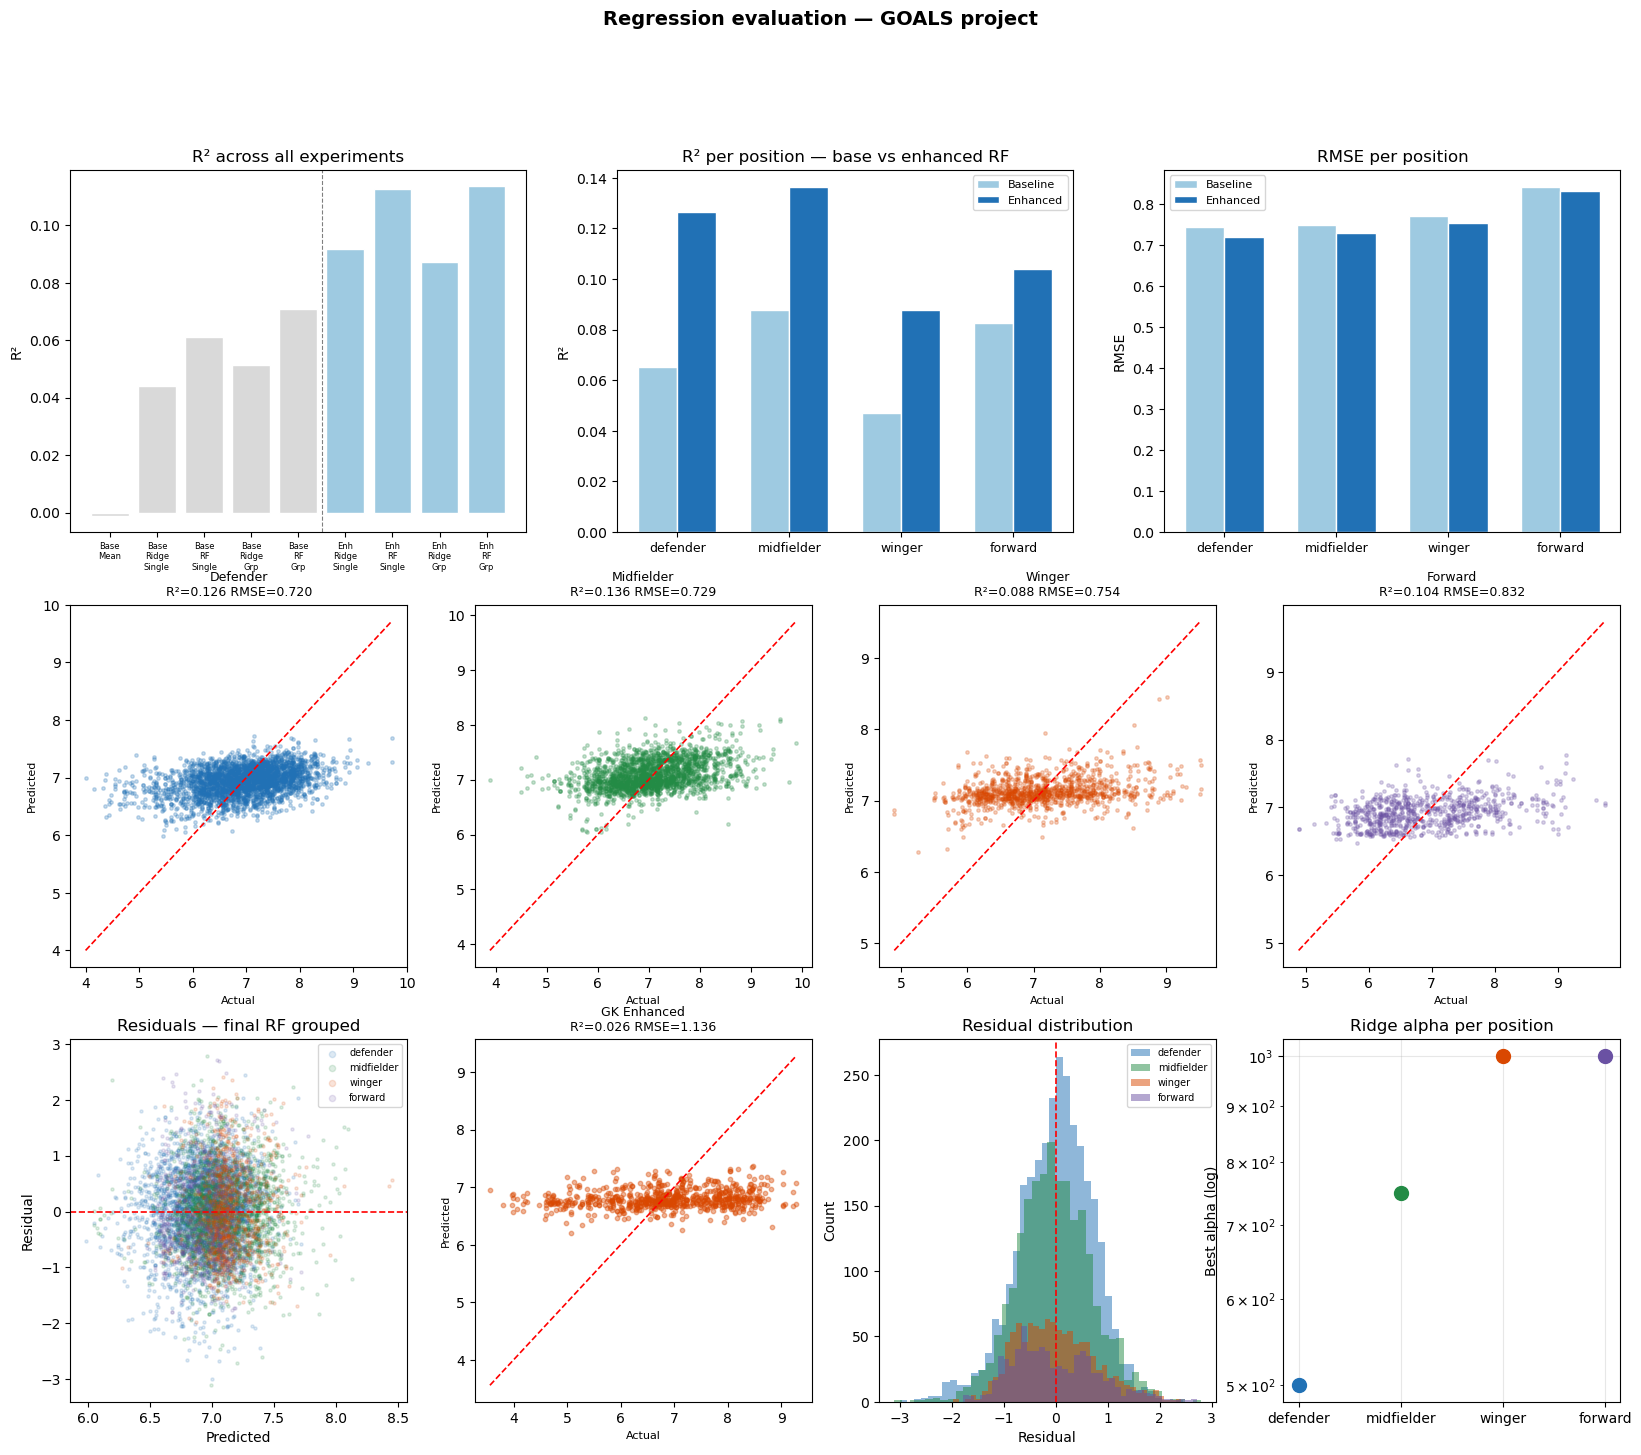

Saved: regression_full_evaluation.png


In [30]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Regression evaluation — GOALS project', fontsize=14, fontweight='bold')

# R² progression
ax1 = fig.add_subplot(3, 3, 1)
exp_labels = ['Base\nMean','Base\nRidge\nSingle','Base\nRF\nSingle',
              'Base\nRidge\nGrp','Base\nRF\nGrp',
              'Enh\nRidge\nSingle','Enh\nRF\nSingle',
              'Enh\nRidge\nGrp','Enh\nRF\nGrp']
r2_vals = [c[2] for c in comparison]
colors  = ['#d9d9d9']*5 + ['#9ecae1']*4
ax1.bar(range(len(exp_labels)), r2_vals, color=colors, edgecolor='white')
ax1.set_xticks(range(len(exp_labels)))
ax1.set_xticklabels(exp_labels, fontsize=6)
ax1.set_ylabel('R²')
ax1.set_title('R² across all experiments')
ax1.axvline(4.5, color='black', linestyle='--', lw=0.8, alpha=0.5)

# R² per position — base vs enhanced
ax2 = fig.add_subplot(3, 3, 2)
x     = np.arange(len(GROUPS))
w     = 0.35
r2_b  = [r['r2'] for r in results_rf_grouped]
r2_e  = [r['r2'] for r in results_rf_enh_grouped]
ax2.bar(x-w/2, r2_b, w, label='Baseline', color='#9ecae1', edgecolor='white')
ax2.bar(x+w/2, r2_e, w, label='Enhanced', color='#2171b5', edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(GROUPS, fontsize=9)
ax2.set_ylabel('R²'); ax2.set_title('R² per position — base vs enhanced RF')
ax2.legend(fontsize=8)

# RMSE per position
ax3 = fig.add_subplot(3, 3, 3)
rm_b = [r['rmse'] for r in results_rf_grouped]
rm_e = [r['rmse'] for r in results_rf_enh_grouped]
ax3.bar(x-w/2, rm_b, w, label='Baseline', color='#9ecae1', edgecolor='white')
ax3.bar(x+w/2, rm_e, w, label='Enhanced', color='#2171b5', edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels(GROUPS, fontsize=9)
ax3.set_ylabel('RMSE'); ax3.set_title('RMSE per position')
ax3.legend(fontsize=8)

# Predicted vs actual per position
for idx, group in enumerate(GROUPS):
    ax = fig.add_subplot(3, 4, 5+idx)
    te = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    act = te['rating_title'].values
    ax.scatter(act, preds, alpha=0.25, s=6, color=GROUP_COLORS[group])
    mn, mx = act.min(), act.max()
    ax.plot([mn,mx],[mn,mx],'r--',lw=1.2)
    ax.set_title(f'{group.capitalize()}\nR²={r2_score(act,preds):.3f} RMSE={np.sqrt(mean_squared_error(act,preds)):.3f}', fontsize=9)
    ax.set_xlabel('Actual', fontsize=8); ax.set_ylabel('Predicted', fontsize=8)

# Residuals
ax8 = fig.add_subplot(3, 4, 9)
for group in GROUPS:
    te = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    resid = te['rating_title'].values - preds
    ax8.scatter(preds, resid, alpha=0.15, s=5, color=GROUP_COLORS[group], label=group)
ax8.axhline(0, color='red', linestyle='--', lw=1.2)
ax8.set_xlabel('Predicted'); ax8.set_ylabel('Residual')
ax8.set_title('Residuals — final RF grouped')
ax8.legend(fontsize=7, markerscale=2)

# GK predicted vs actual
ax9 = fig.add_subplot(3, 4, 10)
y_pred_gk_enh = rf_enh_single_gk.predict(X_test_gk_e)
ax9.scatter(y_test_gk, y_pred_gk_enh, alpha=0.4, s=10, color='#d94801')
mn, mx = y_test_gk.min(), y_test_gk.max()
ax9.plot([mn,mx],[mn,mx],'r--',lw=1.2)
ax9.set_title(f'GK Enhanced\nR²={r2_score(y_test_gk,y_pred_gk_enh):.3f} RMSE={np.sqrt(mean_squared_error(y_test_gk,y_pred_gk_enh)):.3f}', fontsize=9)
ax9.set_xlabel('Actual', fontsize=8); ax9.set_ylabel('Predicted', fontsize=8)

# Residual distribution
ax10 = fig.add_subplot(3, 4, 11)
for group in GROUPS:
    te = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    ax10.hist(te['rating_title'].values - preds, bins=40, alpha=0.5,
              color=GROUP_COLORS[group], label=group, edgecolor='none')
ax10.axvline(0, color='red', linestyle='--', lw=1.2)
ax10.set_xlabel('Residual'); ax10.set_ylabel('Count')
ax10.set_title('Residual distribution'); ax10.legend(fontsize=7)

# Ridge alpha per position
ax11 = fig.add_subplot(3, 4, 12)
for group in GROUPS:
    ax11.scatter([group], [ridge_enh_grouped_models[group].alpha_],
                 color=GROUP_COLORS[group], s=100, zorder=5)
ax11.set_yscale('log'); ax11.set_ylabel('Best alpha (log)')
ax11.set_title('Ridge alpha per position'); ax11.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'regression_full_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regression_full_evaluation.png')

### Cell 17 — Feature importance & Ridge coefficients

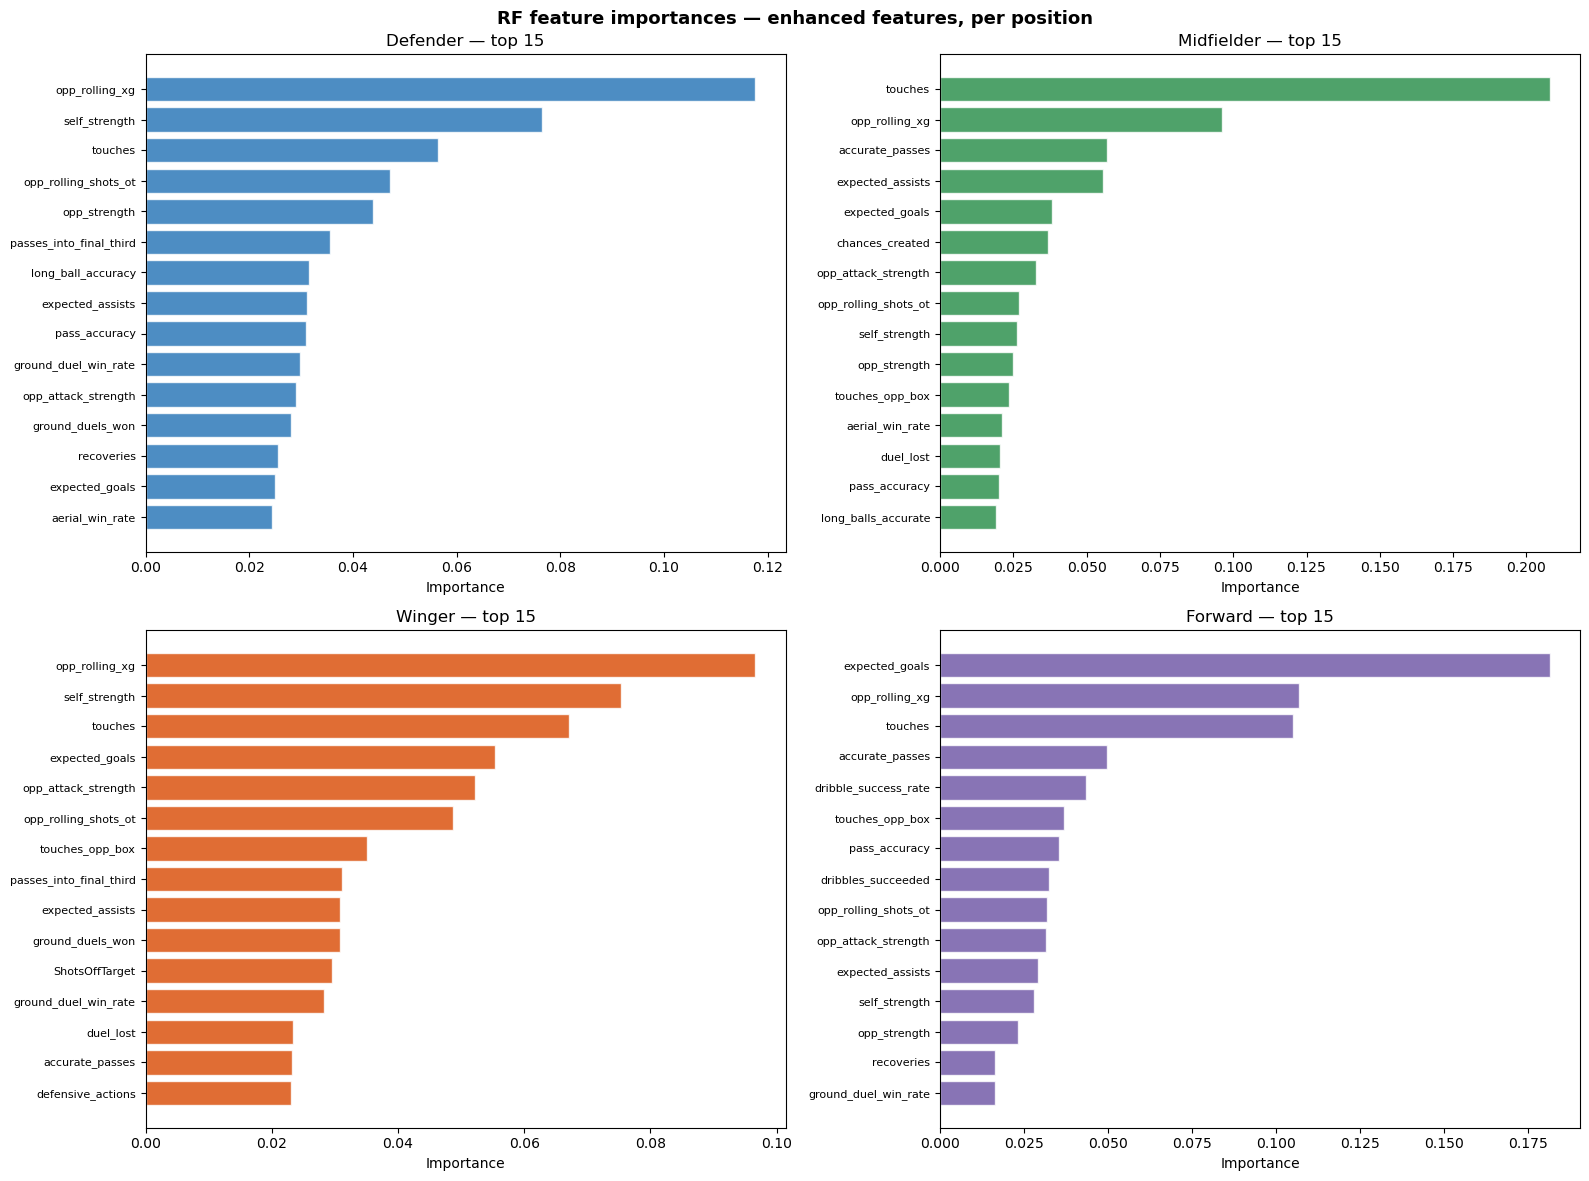

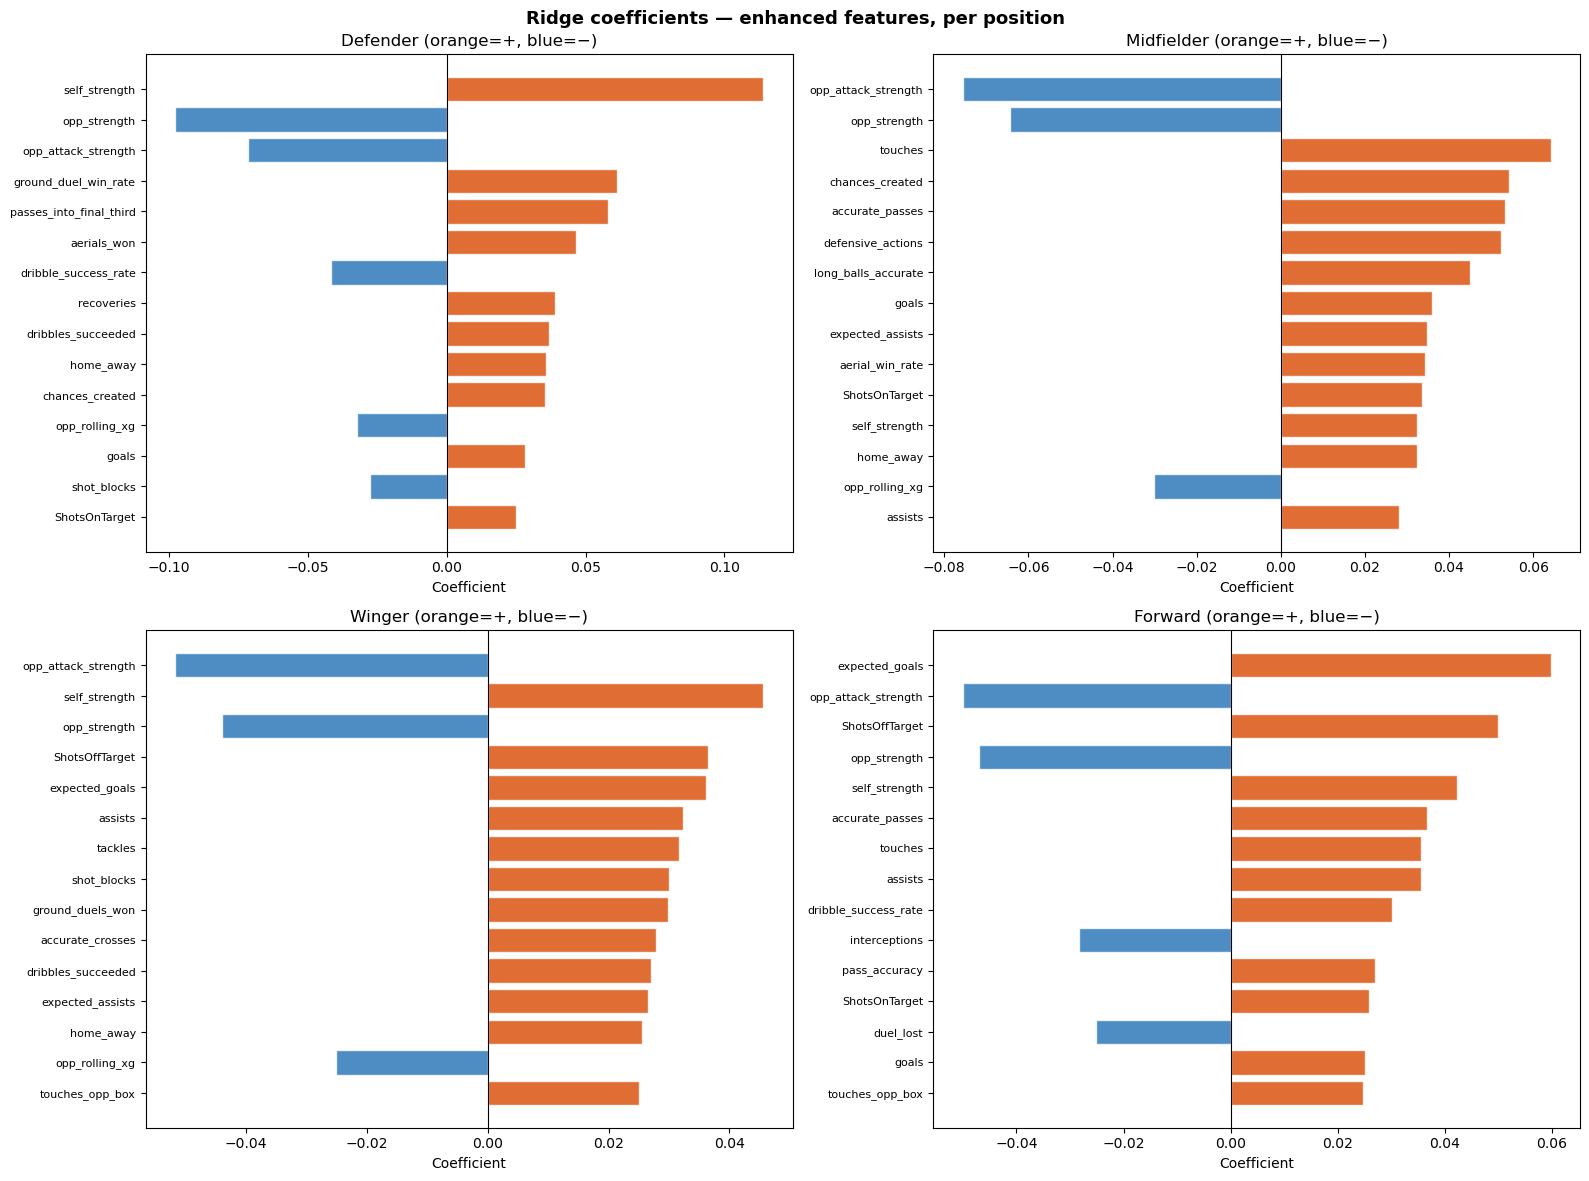

Saved: feature_importances_final.png, ridge_coefficients_final.png


In [31]:
# RF feature importances — top 15 per position
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RF feature importances — enhanced features, per position', fontsize=13, fontweight='bold')
for ax, group in zip(axes.flatten(), GROUPS):
    rf   = rf_enh_grouped_models[group]['model']
    imps = rf.feature_importances_
    idx  = np.argsort(imps)[-15:]
    ax.barh(range(15), imps[idx], color=GROUP_COLORS[group], alpha=0.8, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels([FEATURE_COLS_ENH_OUT[i] for i in idx], fontsize=8)
    ax.set_xlabel('Importance'); ax.set_title(f'{group.capitalize()} — top 15')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'feature_importances_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Ridge coefficients — top 15 by magnitude per position
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ridge coefficients — enhanced features, per position', fontsize=13, fontweight='bold')
for ax, group in zip(axes.flatten(), GROUPS):
    ridge = ridge_enh_grouped_models[group]
    coefs = ridge.coef_
    idx   = np.argsort(np.abs(coefs))[-15:]
    colors = ['#d94801' if coefs[i] > 0 else '#2171b5' for i in idx]
    ax.barh(range(15), coefs[idx], color=colors, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels([FEATURE_COLS_ENH_OUT[i] for i in idx], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Coefficient'); ax.set_title(f'{group.capitalize()} (orange=+, blue=−)')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_coefficients_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importances_final.png, ridge_coefficients_final.png')

### Cell 18 — Export models and predictions

In [32]:
# Save models
joblib.dump({g: rf_enh_grouped_models[g]['model'] for g in GROUPS},
            MODELS_DIR / 'rf_outfield_grouped_final.pkl')
joblib.dump({g: rf_grouped_models[g]['model'] for g in GROUPS},
            MODELS_DIR / 'rf_outfield_grouped_baseline.pkl')
joblib.dump(ridge_enh_grouped_models,  MODELS_DIR / 'ridge_outfield_grouped_final.pkl')
joblib.dump(ridge_grouped_models,      MODELS_DIR / 'ridge_outfield_grouped_baseline.pkl')
joblib.dump(rf_enh_single_gk,          MODELS_DIR / 'rf_gk_final.pkl')
joblib.dump(ridge_enh_single_gk,       MODELS_DIR / 'ridge_gk_final.pkl')
joblib.dump(FEATURE_COLS_ENH_OUT,      MODELS_DIR / 'feature_cols_outfield_final.pkl')
joblib.dump(FEATURE_COLS_ENH_GK,       MODELS_DIR / 'feature_cols_gk_final.pkl')

# Add predictions to dataframes
for df_name, df in [('outfield_train', outfield_train), ('outfield_test', outfield_test)]:
    for c in ['pred_rating_ridge_base','pred_rating_rf_base',
              'pred_rating_ridge_enh','pred_rating_rf_enh']:
        if c in df.columns: df = df.drop(columns=[c])

    df['pred_rating_ridge_base'] = np.nan
    df['pred_rating_rf_base']    = np.nan
    df['pred_rating_ridge_enh']  = np.nan
    df['pred_rating_rf_enh']     = np.nan

    for group in GROUPS:
        mask   = df['position_group'] == group
        X_base = df.loc[mask, FEATURE_COLS_OUT].values
        X_enh  = df.loc[mask, FEATURE_COLS_ENH_OUT].values
        df.loc[mask, 'pred_rating_ridge_base'] = ridge_grouped_models[group].predict(X_base)
        df.loc[mask, 'pred_rating_rf_base']    = rf_grouped_models[group]['model'].predict(X_base)
        df.loc[mask, 'pred_rating_ridge_enh']  = ridge_enh_grouped_models[group].predict(X_enh)
        df.loc[mask, 'pred_rating_rf_enh']     = rf_enh_grouped_models[group]['model'].predict(X_enh)
    globals()[df_name] = df

gk_train['pred_rating_ridge_enh'] = ridge_enh_single_gk.predict(X_train_gk_e)
gk_train['pred_rating_rf_enh']    = rf_enh_single_gk.predict(X_train_gk_e)
gk_test['pred_rating_ridge_enh']  = ridge_enh_single_gk.predict(X_test_gk_e)
gk_test['pred_rating_rf_enh']     = rf_enh_single_gk.predict(X_test_gk_e)

outfield_train.to_parquet(PROCESSED_DIR / 'outfield_train_with_predictions.parquet', index=False)
outfield_test.to_parquet(PROCESSED_DIR  / 'outfield_test_with_predictions.parquet',  index=False)
gk_train.to_parquet(PROCESSED_DIR       / 'gk_train_with_predictions.parquet',       index=False)
gk_test.to_parquet(PROCESSED_DIR        / 'gk_test_with_predictions.parquet',        index=False)

print('Models saved:')
for f in sorted(MODELS_DIR.glob('*.pkl')):
    print(f'  {f.name}')
print('\nPrediction parquets saved:')
for name in ['outfield_train_with_predictions','outfield_test_with_predictions',
             'gk_train_with_predictions','gk_test_with_predictions']:
    p = PROCESSED_DIR / f'{name}.parquet'
    print(f'  {name}.parquet — {pd.read_parquet(p).shape}')

Models saved:
  feature_cols_gk_final.pkl
  feature_cols_outfield_final.pkl
  position_map.pkl
  rf_gk_final.pkl
  rf_outfield_grouped_baseline.pkl
  rf_outfield_grouped_final.pkl
  ridge_gk_final.pkl
  ridge_outfield_grouped_baseline.pkl
  ridge_outfield_grouped_final.pkl
  scaler_gk.pkl
  scalers_outfield.pkl

Prediction parquets saved:
  outfield_train_with_predictions.parquet — (21847, 66)
  outfield_test_with_predictions.parquet — (7034, 66)
  gk_train_with_predictions.parquet — (2193, 55)
  gk_test_with_predictions.parquet — (713, 55)
